# SMIB

In [1]:
import pypowsybl.network as pn
import math
import pypowsybl.dynamic as dyn
from pypowsybl_jupyter import display_nad
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

Define helper functions 

In [2]:
from helpers import *

Create SMIB network

In [3]:
network = pn.create_empty()

network.create_substations(id=['S1', 'S2'], name=['S1', 'S2'],  country=['FR', 'FR'], tso=["SMIB", "SMIB"])

network.create_voltage_levels(id='VL1', name='VL1', substation_id='S1', topology_kind='BUS_BREAKER',
                              nominal_v=1, low_voltage_limit=0.8, high_voltage_limit=1.2)
network.create_voltage_levels(id='VL2', name='VL2', substation_id='S2', topology_kind='BUS_BREAKER',
                              nominal_v=1, low_voltage_limit=0.8, high_voltage_limit=1.2)
network.create_voltage_levels(id='VL3', name='VL3', substation_id='S2', topology_kind='BUS_BREAKER',
                              nominal_v=1, low_voltage_limit=0.8, high_voltage_limit=1.2)

network.create_buses(id='VL1_BUS1', voltage_level_id='VL1')

network.create_buses(id='VL2_BUS1', voltage_level_id='VL2')

network.create_buses(id='VL3_BUS1', voltage_level_id='VL3')

network.create_lines(id='line1', voltage_level1_id='VL1', bus1_id='VL1_BUS1',
                     voltage_level2_id='VL2', bus2_id='VL2_BUS1',
                     b1=0, b2=0, g1=0, g2=0, r=0, x=0.022522)

network.create_lines(id='line2', voltage_level1_id='VL1', bus1_id='VL1_BUS1',
                     voltage_level2_id='VL2', bus2_id='VL2_BUS1',
                     b1=0, b2=0, g1=0, g2=0, r=0, x=0.04189)

network.create_2_windings_transformers(id='TR', voltage_level1_id='VL2', bus1_id='VL2_BUS1',
                                       voltage_level2_id='VL3', bus2_id='VL3_BUS1',
                                       b=0, g=0, r=0, x=0.00675, rated_u1=1, rated_u2=1)

network.create_generators(id='SM', voltage_level_id='VL3', bus_id='VL3_BUS1',
                          target_p=2200, min_p=0, max_p=2220, target_v=1, target_q=967.903359, energy_source='NUCLEAR',
                          voltage_regulator_on=True)

network.update_buses(id='VL1_0', v_mag=0.90081, v_angle=0)
network.update_buses(id='VL2_0', v_mag=1, v_angle=0.494451 * 180. / math.pi)
network.update_buses(id='VL3_0', v_mag=1, v_angle=0.494451 * 180. / math.pi)

SnRef = 100.
l1_p1 = -12.993888 * SnRef
l1_q1 = 0.563960 * SnRef
l1_p2 = 12.993888 * SnRef
l1_q2 = 4.131046 * SnRef
network.update_lines(id='line1', p1=l1_p1, q1=l1_q1 , p2=l1_p2, q2=l1_q2)

l2_p1 = -6.986115 * SnRef
l2_q1 = 0.303211 * SnRef
l2_p2 = 6.986115 * SnRef
l2_q2 = 2.221041 * SnRef
network.update_lines(id='line2', p1=l2_p1, q1=l2_q1, p2=l2_p2, q2=l2_q2)

transformer_terminal1_V_re = 0.886710
transformer_terminal1_V_im = 0.324872
transformer_terminal1_i_re = -22.180041
transformer_terminal1_i_im = -0.962656

transformer_P1Pu = (transformer_terminal1_V_re * transformer_terminal1_i_re
                    + transformer_terminal1_V_im * transformer_terminal1_i_im) * SnRef
transformer_Q1Pu = (transformer_terminal1_V_im * transformer_terminal1_i_re
                    - transformer_terminal1_V_re * transformer_terminal1_i_im) * SnRef

transformer_terminal2_V_re = 0.880212
transformer_terminal2_V_im = 0.474588
transformer_terminal2_i_re = 22.180041
transformer_terminal2_i_im = 0.962656

transformer_P2Pu = (transformer_terminal2_V_re * transformer_terminal2_i_re
                    + transformer_terminal2_V_im * transformer_terminal2_i_im) * SnRef
transformer_Q2Pu = (transformer_terminal2_V_im * transformer_terminal2_i_re
                               - transformer_terminal2_V_re * transformer_terminal2_i_im) * SnRef

network.update_2_windings_transformers(id='TR', p1=transformer_P1Pu, q1=transformer_Q1Pu, p2=transformer_P2Pu, q2=transformer_Q2Pu)

network.update_generators(id='SM', p=-1998.000296, q=-967.903359)

filename_out = 'smib.xiidm'
network.save(filename_out, format='XIIDM', parameters={'iidm.export.xml.version': '1.4'})
fixIIDMSourceFormat(filename_out)

In [4]:
display_nad(network.get_network_area_diagram())

NadWidget(diagram_data={'svg_data': '<?xml version="1.0" encoding="UTF-8"?>\n<svg width="379.96" height="600.0…

Create Mapping for models

In [5]:
model_mapping = dyn.ModelMapping()

model_mapping.add_infinite_bus(static_id='VL1_BUS1', parameter_set_id='InfiniteBus', model_name='InfiniteBus')

model_mapping.add_base_bus(static_id='VL2_BUS1', parameter_set_id='bus1', model_name='Bus')
model_mapping.add_base_bus(static_id='VL3_BUS1', parameter_set_id='bus2', model_name='Bus')

model_mapping.add_base_line(static_id='line1', parameter_set_id='line1', model_name='Line')
model_mapping.add_base_line(static_id='line2', parameter_set_id='line2', model_name='Line')

model_mapping.add_base_transformer(static_id='TR', parameter_set_id='TR', model_name='TransformerFixedRatio')

model_mapping.add_synchronous_generator(static_id='SM', parameter_set_id='SM', model_name='GeneratorSynchronousFourWindingsProportionalRegulations')

Add event

In [6]:
event_mapping = dyn.EventMapping()
event_mapping.add_active_power_variation(static_id='SM', start_time=1, delta_p=0.02)

Ask curves

In [7]:
variables_mapping = dyn.OutputVariableMapping()
variables_mapping.add_dynamic_model_curves('SM', 'generator_PGen')

In [8]:
parfilePath = '/home/bureaugau/Projects/dynamo/dynawo-notebook/SMIB/SMIB.par'

We put initial model parameters for parametric testing

In [9]:
updateParValue(parfilePath, 'SM', 'generator_H', '3.5')
updateParValue(parfilePath, 'SM', 'governor_KGover', '5')

We are forced to load a new network each time we load the cell as the simulation updates the corresponding network and we would have strange results by executing on the same network multiple times

In [10]:
network2 = pn.load(filename_out)
sim = dyn.Simulation()
res = sim.run(network2, model_mapping, event_mapping, variables_mapping, 0, 30)

In [11]:
print(res.status())

DynamicSimulationStatus.SUCCESS


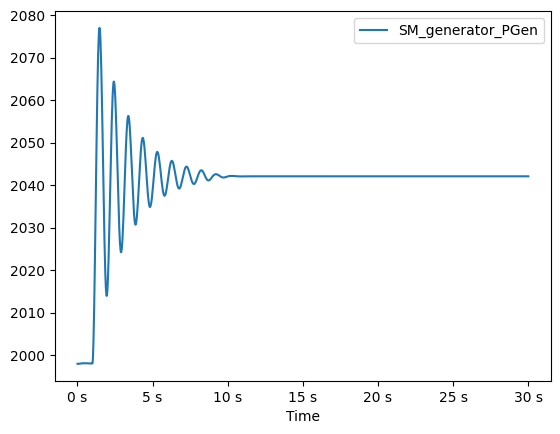

In [12]:
plot(res.curves())

In [13]:
updateParValue(parfilePath, 'SM', 'generator_H', '10')

In [14]:
network3 = pn.load(filename_out)
res2 = sim.run(network3, model_mapping, event_mapping, variables_mapping, 0, 30)

In [15]:
print(res2.status())

DynamicSimulationStatus.SUCCESS


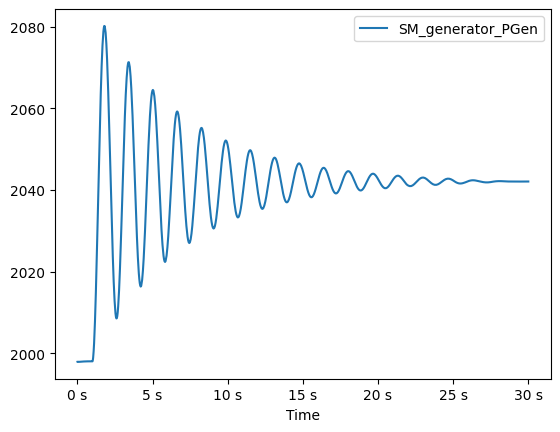

In [16]:
plot(res2.curves())

Now we can compare the two simulations

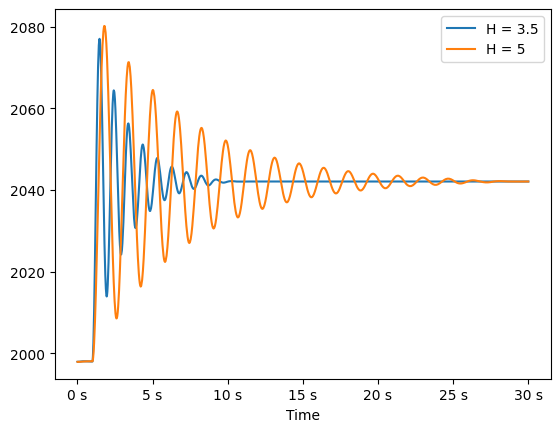

In [17]:
curves1 = res.curves()
curveName = curves1.columns.tolist()[0]
figure = addPlot(res.curves(), curveName, 'H = 3.5')
plotSameGraph(res2.curves(), figure, curveName, 'H = 5')

How to print available models

In [18]:
print(model_mapping.get_supported_models(dyn.DynamicMappingType.SYNCHRONIZED_GENERATOR))

['GeneratorPQ', 'GeneratorPV', 'GeneratorPVDiagramPQ']


In [19]:
print(model_mapping.get_supported_models(dyn.DynamicMappingType.SYNCHRONOUS_GENERATOR))

['GeneratorSynchronousFourWindings', 'GeneratorSynchronousFourWindingsGovSteam1ExcIEEEST4B', 'GeneratorSynchronousFourWindingsGovSteam1ExcIEEEST4BPssIEEE2B', 'GeneratorSynchronousFourWindingsGoverPropVRPropInt', 'GeneratorSynchronousFourWindingsIEEEG1Ac1a', 'GeneratorSynchronousFourWindingsIEEEG1Dc1a', 'GeneratorSynchronousFourWindingsIEEEG1IEEX2A', 'GeneratorSynchronousFourWindingsPmConstAc6aPss3b', 'GeneratorSynchronousFourWindingsPmConstAc7bPss3b', 'GeneratorSynchronousFourWindingsPmConstAc7cPss2c', 'GeneratorSynchronousFourWindingsPmConstAc8b', 'GeneratorSynchronousFourWindingsPmConstAc8bPss3b', 'GeneratorSynchronousFourWindingsPmConstDc1a', 'GeneratorSynchronousFourWindingsPmConstIEEX2A', 'GeneratorSynchronousFourWindingsPmConstSt5bPss2b', 'GeneratorSynchronousFourWindingsPmConstSt6bPss3b', 'GeneratorSynchronousFourWindingsPmConstSt6cPss6c', 'GeneratorSynchronousFourWindingsPmConstSt7bPss2a', 'GeneratorSynchronousFourWindingsPmConstSt9cPss2c', 'GeneratorSynchronousFourWindingsPmCo

In [20]:
print(model_mapping.get_supported_models(dyn.DynamicMappingType.GRID_FORMING_CONVERTER))

['GridFormingConverterDispatchableVirtualOscillatorControl', 'GridFormingConverterDroopControl', 'GridFormingConverterMatchingControl']


Print available parameters for GeneratorSynchronousFourWindingsProportionalRegulations model

In [21]:
gsfwpr_parameters = defineParameters('GeneratorSynchronousFourWindingsProportionalRegulations')
prettyPrintParameters('GeneratorSynchronousFourWindingsProportionalRegulations', gsfwpr_parameters)

GeneratorSynchronousFourWindingsProportionalRegulations parameters:
  generator_DPu
  generator_ExcitationPu
  generator_H
  generator_MdPuEfd
  generator_P0Pu
  generator_PNomAlt
  generator_PNomTurb
  generator_Q0Pu
  generator_RTfPu
  generator_RaPu
  generator_SNom
  generator_SnTfo
  generator_Tpd0
  generator_Tppd0
  generator_Tppq0
  generator_Tpq0
  generator_U0Pu
  generator_UBaseHV
  generator_UBaseLV
  generator_UNom
  generator_UNomHV
  generator_UNomLV
  generator_UPhase0
  generator_UseApproximation
  generator_XTfPu
  generator_XdPu
  generator_XlPu
  generator_XpdPu
  generator_XppdPu
  generator_XppqPu
  generator_XpqPu
  generator_XqPu
  generator_md
  generator_mq
  generator_nd
  generator_nq
  governor_KGover
  governor_PMax
  governor_PMin
  governor_PNom
  voltageRegulator_EfdMaxPu
  voltageRegulator_EfdMinPu
  voltageRegulator_Gain
  voltageRegulator_LagEfdMax
  voltageRegulator_LagEfdMin
  voltageRegulator_UsRefMaxPu
  voltageRegulator_UsRefMinPu


We want to test the influence of governor_KGover, first we print its value:

In [22]:
kgover_name = 'governor_KGover'
printParameterValue(parfilePath, 'SM', kgover_name)

5


Then we update its value and compare the results to the first simulation

In [23]:
updateParValue(parfilePath, 'SM', 'generator_H', '3.5')
updateParValue(parfilePath, 'SM', kgover_name, '10')
network4 = pn.load(filename_out)
res3 = sim.run(network4, model_mapping, event_mapping, variables_mapping, 0, 30)

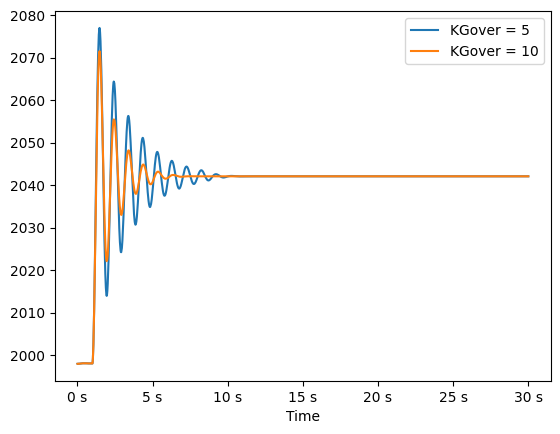

In [24]:
figure2 = addPlot(res.curves(), curveName, 'KGover = 5')
plotSameGraph(res3.curves(), figure2, curveName, 'KGover = 10')

In [25]:
gsfw_parameters = defineParameters('GeneratorSynchronousFourWindings')
prettyPrintParameters('GeneratorSynchronousFourWindings', gsfw_parameters)

GeneratorSynchronousFourWindings parameters:
  generator_DPu
  generator_ExcitationPu
  generator_H
  generator_MdPuEfd
  generator_P0Pu
  generator_PNomAlt
  generator_PNomTurb
  generator_Q0Pu
  generator_RTfPu
  generator_RaPu
  generator_SNom
  generator_SnTfo
  generator_Tpd0
  generator_Tppd0
  generator_Tppq0
  generator_Tpq0
  generator_U0Pu
  generator_UBaseHV
  generator_UBaseLV
  generator_UNom
  generator_UNomHV
  generator_UNomLV
  generator_UPhase0
  generator_UseApproximation
  generator_XTfPu
  generator_XdPu
  generator_XlPu
  generator_XpdPu
  generator_XppdPu
  generator_XppqPu
  generator_XpqPu
  generator_XqPu
  generator_md
  generator_mq
  generator_nd
  generator_nq
